The simplicity of integration

We can estimate the policy directly without storing additional data (action values).

Policy-gradient methods can learn a stochastic policy

Policy-gradient methods can learn a stochastic policy while value functions can’t.

-----------------

We don’t need to implement an exploration/exploitation trade-off by hand. Since we output a probability distribution over actions, the agent explores the state space without always taking the same trajectory.

Policy-gradient methods are more effective in high-dimensional action spaces and continuous actions spaces

Deep Q-learning is that their predictions assign a score (maximum expected future reward) for each possible action,

But what if we have an infinite possibility of actions?

For instance, with a self-driving car

-------------------------------

Disadvantages

Naturally, policy-gradient methods also have some disadvantages:

Frequently, policy-gradient methods converges to a local maximum instead of a global optimum.
Policy-gradient goes slower, step by step: it can take longer to train (inefficient).
Policy-gradient can have high variance. We’ll see in the actor-critic unit why, and how we can solve this problem.

------------






https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html

Policy Gradient (PG) is the foundation of many modern RL algorithms. It directly learns a parameterized policy no Q-values, no value functions.

You learn how to update the policy parameters using the gradient of expected reward:

The policy is represented as: $\pi_{\theta}(a \mid s)$

policy is function, its probability distribution for action given state


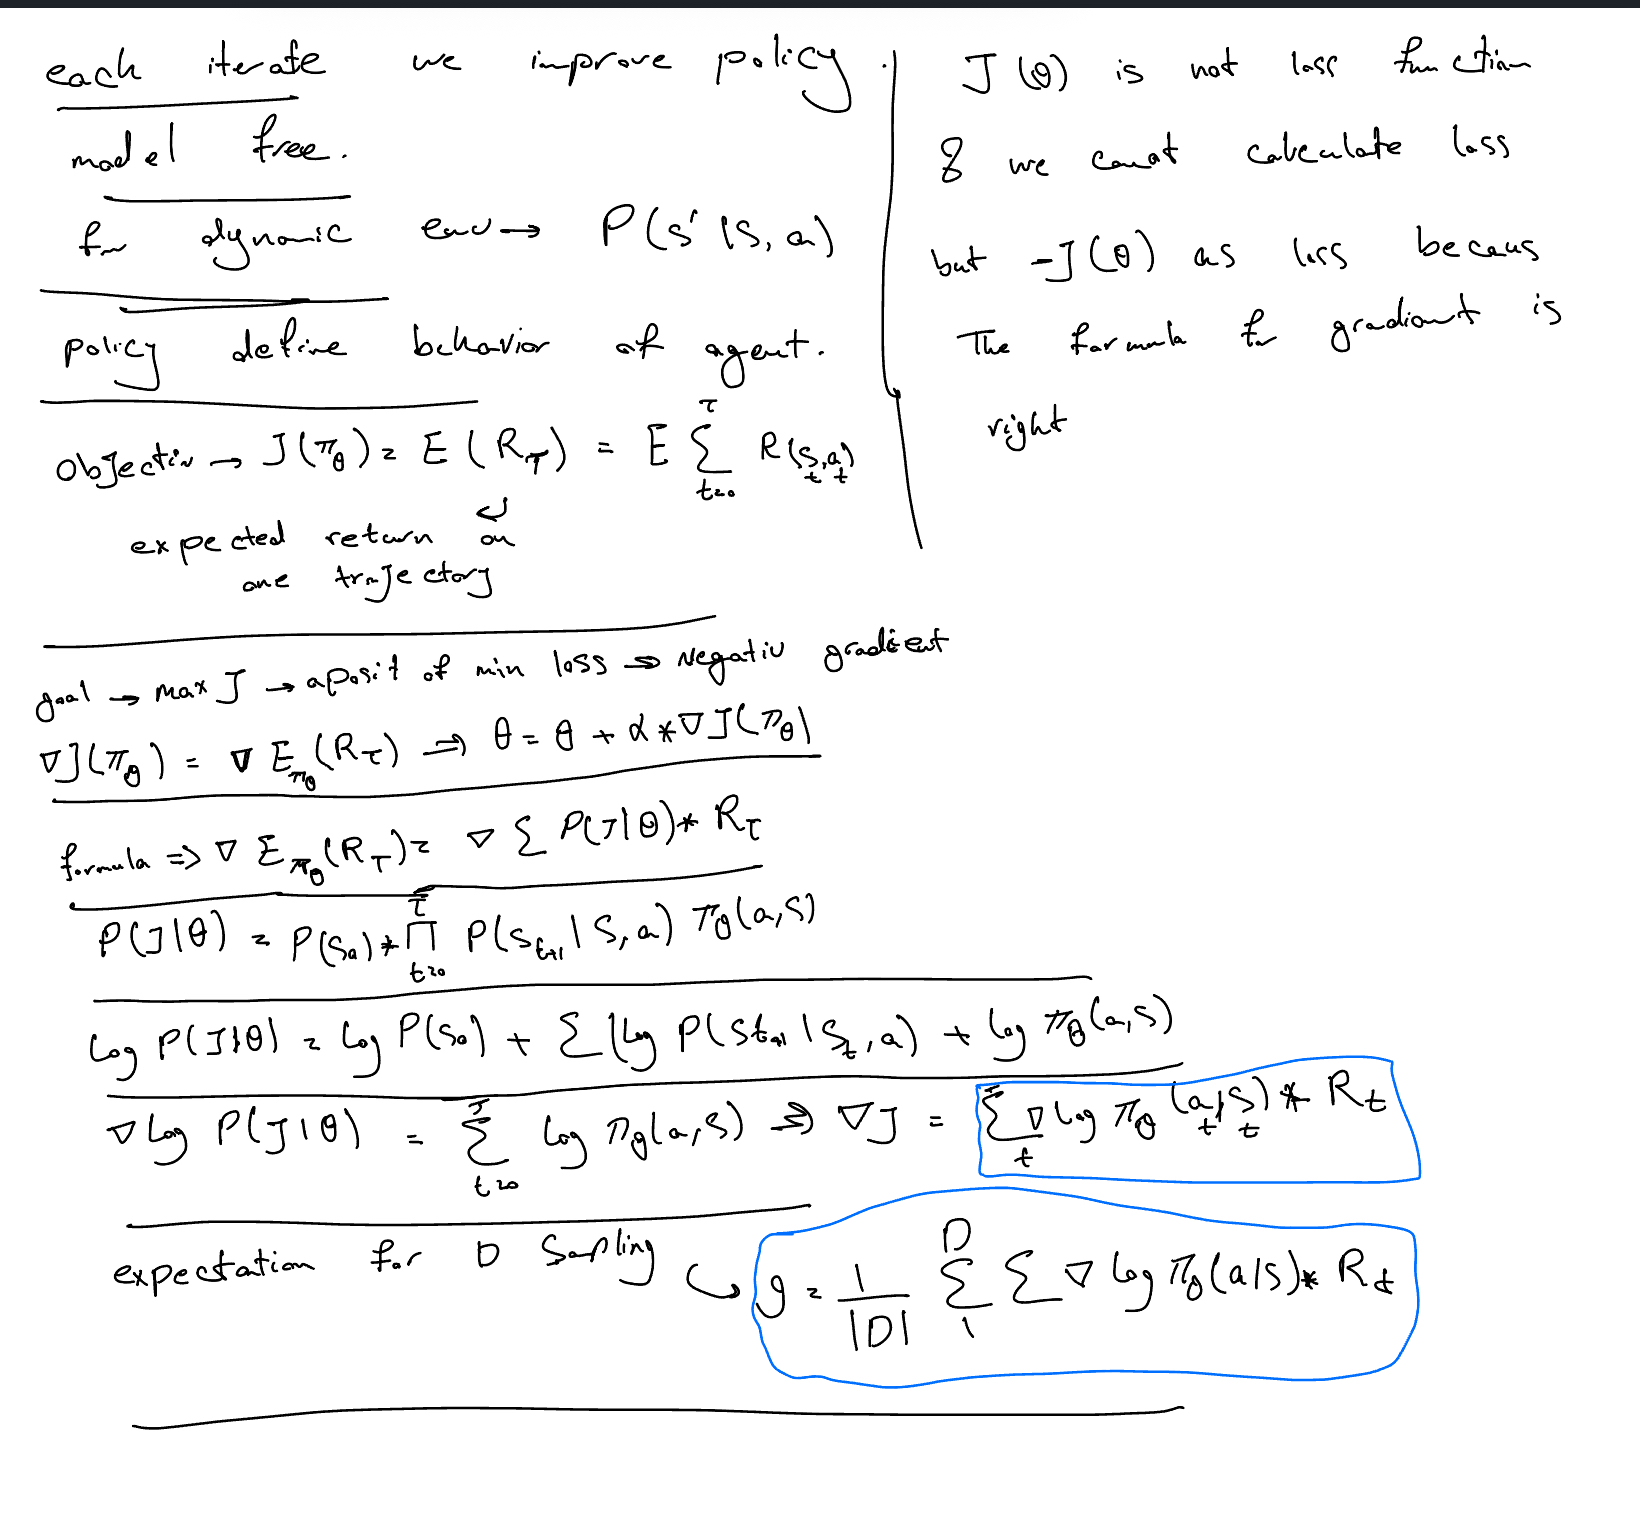


Reinforce with reward to go update

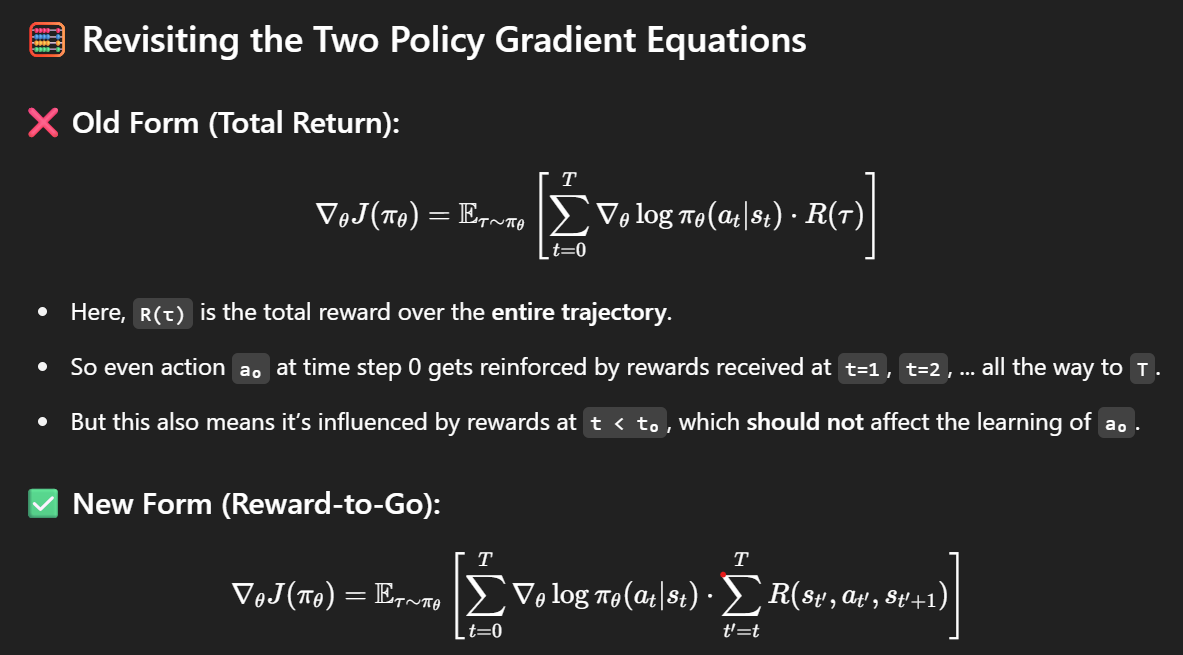

In [1]:
import torch
import torch.nn as nn
from torch.distributions.categorical import Categorical
from torch.optim import Adam
import numpy as np
import gymnasium as gym
from gymnasium.spaces import Discrete, Box

In [31]:
env_name='CartPole-v0'
env = gym.make(env_name)
obs_dim = env.observation_space.shape[0]
n_acts = env.action_space.n
obs_dim,n_acts
#mlp(sizes=[obs_dim]+hidden_sizes+[n_acts] -> hiddne =32

(4, np.int64(2))

In [28]:
def mlp(sizes, activation=nn.Tanh, output_activation=nn.Identity):
    # Build a feedforward neural network.
    layers = []
    for j in range(len(sizes)-1):
        act = activation if j < len(sizes)-2 else output_activation
        layers += [nn.Linear(sizes[j], sizes[j+1]), act()]
    return nn.Sequential(*layers)

In [29]:
def train(hidden_sizes=[32], lr=1e-2, 
          epochs=10, batch_size=5000, render=False):

    legit_net = mlp(sizes=([env.observation_space.shape[0]] + hidden_sizes + [ env.action_space.n]))


    
    def get_policy(obs):
        legit_policy = legit_net(obs)
        return Categorical(logits=legit_policy)
    
    def get_action(obs):
        return get_policy(obs).sample().item()
    
    def compute_loss(obs, act, weights):
        # chose act based on policy
        # weights are reward on one batch trajectory
    
        log_p = get_policy(obs).log_prob(act) # this like keep bugging me.
        return -(log_p * weights).mean()

    optimizer = Adam(legit_net.parameters(),lr=lr)


    def train_one_epoch():
        # make some empty lists for logging.
        batch_obs = []          # for observations
        batch_acts = []         # for actions
        batch_weights = []      # for R(tau) weighting in policy gradient
        batch_rets = []         # for measuring episode returns
        batch_lens = []         # for measuring episode lengths

        # reset episode-specific variables
        obs,_ = env.reset()    # first obs comes from starting distribution
        done = False            # signal from environment that episode is over
        ep_rews = []            # list for rewards accrued throughout ep

        # render first episode of each epoch
        finished_rendering_this_epoch = False
        while True:
            batch_obs.append(obs)

            #print(obs)
            act = get_action(torch.as_tensor(obs, dtype=torch.float32))

            
            obs, rew, done,_, _ = env.step(act)
            

            batch_acts.append(act)
            ep_rews.append(rew)

            if done:
                # if episode is over, record info about episode
                ep_ret, ep_len = sum(ep_rews), len(ep_rews)

                batch_rets.append(ep_ret)
                batch_lens.append(ep_len)

                # the weight for each logprob(a|s) is R(tau)
                batch_weights += [ep_ret] * ep_len

                # reset episode-specific variables
                obs, done, ep_rews = env.reset(), False, []
                #print('----',obs)
                obs,_ = obs
                # won't render again this epoch
                finished_rendering_this_epoch = True

                # end experience loop if we have enough of it
                if len(batch_obs) > batch_size:
                    break

        optimizer.zero_grad()
        batch_loss = compute_loss(obs=torch.as_tensor(batch_obs, dtype=torch.float32),
                                  act=torch.as_tensor(batch_acts, dtype=torch.int32),
                                  weights=torch.as_tensor(batch_weights, dtype=torch.float32)
                                  )
        batch_loss.backward()
        optimizer.step()
        return batch_loss, batch_rets, batch_lens

    for i in range(epochs):
        batch_loss, batch_rets, batch_lens = train_one_epoch()
        print('epoch: %3d \t loss: %.3f \t return: %.3f \t ep_len: %.3f'%
                (i, batch_loss, np.mean(batch_rets), np.mean(batch_lens)))

        

In [30]:
train()

epoch:   0 	 loss: 19.043 	 return: 22.062 	 ep_len: 22.062
epoch:   1 	 loss: 24.968 	 return: 26.595 	 ep_len: 26.595
epoch:   2 	 loss: 21.522 	 return: 25.437 	 ep_len: 25.437
epoch:   3 	 loss: 25.413 	 return: 28.197 	 ep_len: 28.197
epoch:   4 	 loss: 26.589 	 return: 32.019 	 ep_len: 32.019
epoch:   5 	 loss: 29.437 	 return: 35.458 	 ep_len: 35.458
epoch:   6 	 loss: 31.150 	 return: 38.623 	 ep_len: 38.623
epoch:   7 	 loss: 31.166 	 return: 37.336 	 ep_len: 37.336
epoch:   8 	 loss: 35.021 	 return: 42.475 	 ep_len: 42.475
epoch:   9 	 loss: 34.974 	 return: 44.768 	 ep_len: 44.768


In [ ]:
#

In [44]:
a , _= env.reset()

In [46]:
b = a.copy()

In [45]:
a

array([ 0.01924894,  0.03450129,  0.0134044 , -0.03086352], dtype=float32)